In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
df = pd.read_csv("IRIS.csv")
df.head()

<bound method NDFrame.head of      sepal_length  sepal_width  petal_length  petal_width         species
0             5.1          3.5           1.4          0.2     Iris-setosa
1             4.9          3.0           1.4          0.2     Iris-setosa
2             4.7          3.2           1.3          0.2     Iris-setosa
3             4.6          3.1           1.5          0.2     Iris-setosa
4             5.0          3.6           1.4          0.2     Iris-setosa
..            ...          ...           ...          ...             ...
145           6.7          3.0           5.2          2.3  Iris-virginica
146           6.3          2.5           5.0          1.9  Iris-virginica
147           6.5          3.0           5.2          2.0  Iris-virginica
148           6.2          3.4           5.4          2.3  Iris-virginica
149           5.9          3.0           5.1          1.8  Iris-virginica

[150 rows x 5 columns]>

In [2]:
df.isnull()

,sepal_length,sepal_width,petal_length,petal_width,species
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [3]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [46]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Length: 150, dtype: bool

In [8]:
df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [32]:
x = df.drop(columns = "sepal_length")
y = df["sepal_length"]
x = pd.get_dummies(x, columns = ["species"], drop_first = True,)

In [33]:
x.dtypes

sepal_width                float64
petal_length               float64
petal_width                float64
species_Iris-versicolor       bool
species_Iris-virginica        bool
dtype: object

In [34]:
x_train,x_test, y_train,y_test = train_test_split(x,y, test_size=0.2 ,random_state = 40)

In [35]:
linear_regression = LinearRegression()

In [37]:
linear_regression.fit(x_train,y_train)
y_pred = linear_regression.predict(x_test)

In [38]:
comparision = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : y_pred
})
print(comparision)

     Actual  Predicted
38      4.4   4.663686
66      5.6   6.242319
115     6.4   6.435097
117     7.7   7.945194
89      5.5   5.613821
136     6.3   6.765398
68      6.2   5.828034
94      5.6   5.885170
84      5.4   6.242319
28      5.2   4.954718
90      5.5   6.026101
11      4.8   5.122496
40      5.0   4.897676
126     6.2   5.933199
79      5.7   5.320975
144     6.7   6.772563
123     6.3   5.965302
124     6.7   6.872314
76      6.8   6.415352
59      5.2   5.608566
132     6.4   6.504560
105     7.6   7.471959
53      5.5   5.510250
17      5.1   4.981565
64      5.6   5.485407
18      5.7   5.388589
13      4.3   4.520846
116     6.5   6.623993
9       4.9   4.908188
81      5.5   5.385182


In [39]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print(mae)
print(mse)
print(rmse)
print(r2)

0.2578307370021849
0.10197580858821696
0.31933651308332556
0.8472425097295396


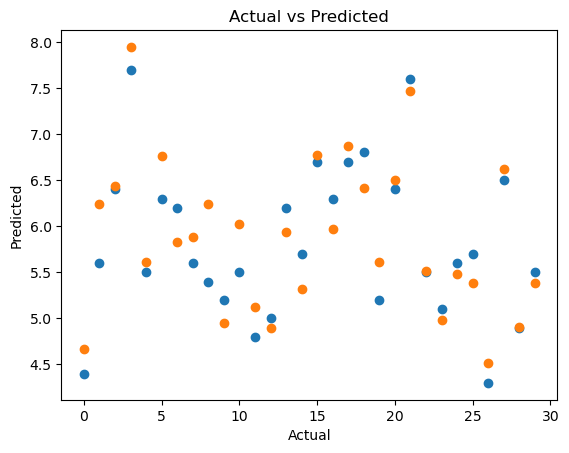

In [44]:
plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(y_pred)), y_pred, label="Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()